# Notebook 3: Exploratory Data Analysis (EDA)
In this notebook, we will analyze the relationship between various columns and the target variable `fraudulent` (0 for real, 1 for fake). This will help us understand which features are most predictive of fake jobs.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data_path = os.path.join("..", "data", "fake_job_postings.csv")
df = pd.read_csv(data_path)

# 1. Check Missing Values
print("=== Missing Values Per Column ===")
print(df.isnull().sum())

=== Missing Values Per Column ===
job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


## 2. Analyzing Categorical and Binary Columns
Let's see if having a company logo or having screening questions is related to whether a job posting is fraudulent.

In [2]:
# Relationship: Company Logo vs Fraudulent
logo_fraud = pd.crosstab(df['has_company_logo'], df['fraudulent'], normalize='index') * 100
print("=== Percentage of Real/Fake Jobs by Company Logo ===")
print(logo_fraud)

# Relationship: Questions vs Fraudulent
questions_fraud = pd.crosstab(df['has_questions'], df['fraudulent'], normalize='index') * 100
print("\n=== Percentage of Real/Fake Jobs by Screening Questions ===")
print(questions_fraud)

=== Percentage of Real/Fake Jobs by Company Logo ===
fraudulent                0          1
has_company_logo                      
0                 84.071038  15.928962
1                 98.009845   1.990155

=== Percentage of Real/Fake Jobs by Screening Questions ===
fraudulent             0         1
has_questions                     
0              93.221831  6.778169
1              97.156506  2.843494


## 3. Analyzing Text Lengths
Do fake job postings have shorter company profiles or descriptions? Let's check the length of these text columns.

In [3]:
# Fill missing text values with empty string for calculation
df['company_profile'] = df['company_profile'].fillna('')
df['description'] = df['description'].fillna('')

# Calculate character lengths
df['profile_len'] = df['company_profile'].apply(len)
df['desc_len'] = df['description'].apply(len)

# Compare average lengths for real vs fake jobs
print("=== Average Company Profile Length ===")
print(df.groupby('fraudulent')['profile_len'].mean())

print("\n=== Average Description Length ===")
print(df.groupby('fraudulent')['desc_len'].mean())

=== Average Company Profile Length ===
fraudulent
0    640.752674
1    230.891455
Name: profile_len, dtype: float64

=== Average Description Length ===
fraudulent
0    1221.219701
1    1154.834873
Name: desc_len, dtype: float64


## 4. Visualizing the Insights
Let's visualize the logo vs. fraud relationship.

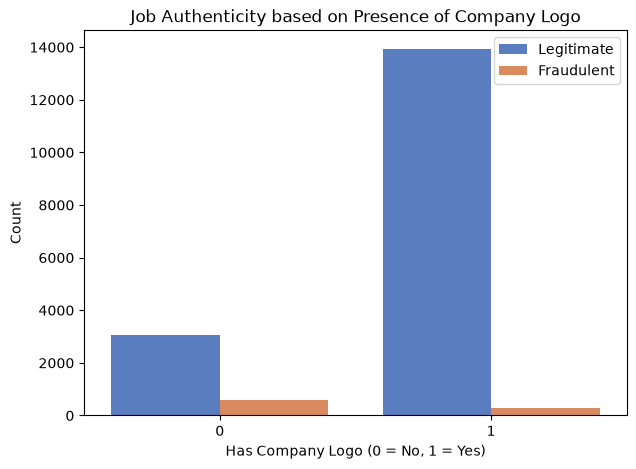

In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(x='has_company_logo', hue='fraudulent', data=df, palette='muted')
plt.title('Job Authenticity based on Presence of Company Logo')
plt.xlabel('Has Company Logo (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.legend(['Legitimate', 'Fraudulent'])
plt.show()